# Bactomata // Data Analysis

In [1]:
pip install growthcurves

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import os

from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

## User-defined parameters

The main user-defined parameter is `expeID`, which identifies the experiment being analyzed. This name is used to locate the experiment folder, build the expected input and output file names, and label the parsed data object. To analyze a different experiment, update `expeID` so it matches the folder and filenames for that experiment.

In [3]:
expeID = "Bactomata_Example"

num_plates = 2

plate_reader_files = {
    "Plate1": "DO_kinetic_48h_rhizobia_SynComs_9_strains_3_replicates_25042026.txt",
    "Plate2": "DO_kinetic_48h_rhizobia_SynComs_9_strains_3_replicates_25042026.txt",
}

Define the project root in Google Drive and change the working directory so all later paths can be written relative to the Bactomata folder.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dirName='/content/drive/Shareddrives/ESB_Code/Bactomata/'
PROJECT_ROOT = Path(dirName)

os.chdir(PROJECT_ROOT)
print('Current directory:', Path.cwd())

Current directory: /content/drive/Shareddrives/ESB_Code/Bactomata


## Project and experiment file structure

Bactomata uses a project-level folder that contains the reusable source code, notebooks, and one folder per experiment. Each experiment is stored under `experiments/<expeID>/`, so the raw inputs, parsed data, exported tables, figures, and notes for a given experiment remain together.

A typical project structure is:

```text
Bactomata/
├── bactomata/
│   ├── __init__.py
│   ├── parser.py
│   ├── processing.py
│   └── plotter.py
│
├── notebooks/
│   └── Bactomata_DataLoader_Example.ipynb
│
└── experiments/
    └── <expeID>/
        ├── raw/
        │   ├── plate_reader/
        │   │   └── <BioTek_export_file>.txt
        │   │
        │   └── layouts/
        │       ├── Bactomata_<expeID>_media_layout.txt
        │       ├── Bactomata_<expeID>_bacteria_layout.txt
        │       ├── Bactomata_<expeID>_media_key_dict.txt
        │       ├── Bactomata_<expeID>_bacteria_key_dict.txt
        │       └── Bactomata_<expeID>_trough_layout.txt
        │
        ├── processed/
        │   ├── Bactomata_<expeID>_parsed.pkl
        │   ├── Bactomata_<expeID>_annotated_data.csv
        │   └── Bactomata_<expeID>_well_annotations.csv
        │
        ├── figures/
        └── notes/

The experiment identifier is used to define the folder structure for the current experiment. These paths point to the raw input files, layout files, processed outputs, figures, and notes. The output folders are created automatically if they do not already exist.

In [6]:

EXPERIMENT_DIR = Path("experiments") / expeID

RAW_DIR = EXPERIMENT_DIR / "raw"
LAYOUT_DIR = RAW_DIR / "layouts"
PLATE_READER_DIR = RAW_DIR / "plate_reader"
PROCESSED_DIR = EXPERIMENT_DIR / "processed"
FIGURES_DIR = EXPERIMENT_DIR / "figures"
NOTES_DIR = EXPERIMENT_DIR / "notes"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTES_DIR.mkdir(parents=True, exist_ok=True)

The input files for the current experiment are defined from the experiment-specific folders. These include the raw BioTek export, the media and bacteria layouts, the corresponding key dictionaries, and the trough layout used during plate setup.

In [7]:
#plate_reader_path = PLATE_READER_DIR / data_file

media_layout_path = LAYOUT_DIR / f"{expeID}_media_layout.txt"
bacteria_layout_path = LAYOUT_DIR / f"{expeID}_bacteria_layout.txt"
media_key_dict_path = LAYOUT_DIR / f"{expeID}_media_key_dict.txt"
bacteria_key_dict_path = LAYOUT_DIR / f"{expeID}_bacteria_key_dict.txt"
trough_layout_path = LAYOUT_DIR / f"{expeID}_trough_layout.txt"

Import the processing and plotting modules. During development, the modules are reloaded so that changes made to the `.py` source files are available in the current notebook session.


In [8]:
import importlib
import bactomata.processing as bp
import bactomata.plotter as bplt
import bactomata.parser as bprs

importlib.reload(bp)
importlib.reload(bplt)
importlib.reload(bprs)


<module 'bactomata.parser' from '/content/drive/Shareddrives/ESB_Code/Bactomata/bactomata/parser.py'>

# BioTek Data Loading


The function `build_experiment_object()` combines the raw BioTek export with the media layout, bacteria layout, key dictionaries, and trough layout. The output is a structured experiment object in which each measurement is linked to its well position, media condition, and bacteria condition.

In [9]:
experiments = []

for plate_id, data_file in plate_reader_files.items():

    plate_reader_path = PLATE_READER_DIR / data_file

    this_experiment = bprs.build_experiment_object(
        expeID=expeID,
        plate_reader_path=plate_reader_path,
        media_layout_path=media_layout_path,
        bacteria_layout_path=bacteria_layout_path,
        media_key_dict_path=media_key_dict_path,
        bacteria_key_dict_path=bacteria_key_dict_path,
        trough_layout_path=trough_layout_path,
        plate_id=plate_id,
    )

    experiments.append(this_experiment)

experiment = bprs.combine_experiments(
    experiments,
    expeID=expeID,
)

The parsed experiment is saved in the processed folder for the current experiment. The PKL file stores the complete Bactomata object for later analysis, while the exported tables provide human-readable versions of the annotated data and well annotations.

In [12]:
# Output paths for this experiment
PROCESSED_DIR = EXPERIMENT_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_pkl_path = PROCESSED_DIR / f"Bactomata_{expeID}_parsed.pkl"
output_tables_dir = PROCESSED_DIR

bprs.save_experiment_pkl(experiment, output_pkl_path)
bprs.export_experiment_tables(experiment, output_tables_dir)

print("Saved PKL to:", output_pkl_path)
print("Saved tables to:", output_tables_dir)

Saved PKL to: experiments/Bactomata_Example/processed/Bactomata_Bactomata_Example_parsed.pkl
Saved tables to: experiments/Bactomata_Example/processed


## Bactomata Data Processing

The variable `experiment` is the central data structure produced by the Bactomata parser. It is a dictionary that stores the parsed experiment in a standardized format:

- `experiment["data"]`: annotated measurement table, with one row per well, time point, and signal.
- `experiment["well_annotations"]`: plate map linking each well to its media condition and bacteria condition.
- `experiment["layouts"]`: original media, bacteria, and trough layouts.
- `experiment["key_dicts"]`: definitions of the media and bacteria keys used in the layouts.
- `experiment["metadata"]`: basic information extracted from the plate-reader file.
- `experiment["warnings"]`: validation warnings generated during parsing.
- `experiment["extra"]`: optional space for adding derived variables or later analyses.

In this section, we use this object to extract the measurements associated with selected media and bacteria conditions, inspect replicate wells, reshape the data into different formats, and calculate simple summaries across replicates.

### Load a previously parsed experiment

The function `load_experiment_pkl()` loads an existing Bactomata experiment object from a PKL file. This allows downstream processing and plotting to start from a previously saved parsed experiment.

In [13]:
bprs.load_experiment_pkl(output_pkl_path)

{'expeID': 'Bactomata_Example',
 'plate_format': 96,
 'plate_id': 'Plate1',
 'data':                   expeID plate_id time_hhmmss  time  temperature well row  \
 0      Bactomata_Example   Plate1     0:00:00   0.0         30.0   A1   A   
 1      Bactomata_Example   Plate1     0:00:00   0.0         30.0   A2   A   
 2      Bactomata_Example   Plate1     0:00:00   0.0         30.0   A3   A   
 3      Bactomata_Example   Plate1     0:00:00   0.0         30.0   A4   A   
 4      Bactomata_Example   Plate1     0:00:00   0.0         30.0   A5   A   
 ...                  ...      ...         ...   ...          ...  ...  ..   
 27835  Bactomata_Example   Plate2    48:00:00  48.0         30.0   H8   H   
 27836  Bactomata_Example   Plate2    48:00:00  48.0         30.0   H9   H   
 27837  Bactomata_Example   Plate2    48:00:00  48.0         30.0  H10   H   
 27838  Bactomata_Example   Plate2    48:00:00  48.0         30.0  H11   H   
 27839  Bactomata_Example   Plate2    48:00:00  48.0      

### Extract time-series data for one condition

The function `get_growth_data()` extracts the time-series data for a selected media and bacteria condition. The returned table keeps replicate wells as separate observations.

In [14]:
growth = bp.get_growth_data(
    experiment,
    media_key="M1",
    bacteria_key="B1",
    signal="OD630",
)

growth.head()

,expeID,plate_id,time_hhmmss,time,well,signal,OD630,media_key,bacteria_key,row,column
0,Bactomata_Example,Plate1,0:00:00,0.000000,A2,OD630,0.114,M1,B1,A,2
1,Bactomata_Example,Plate1,0:20:00,0.333333,A2,OD630,0.118,M1,B1,A,2
2,Bactomata_Example,Plate1,0:40:00,0.666667,A2,OD630,0.122,M1,B1,A,2
3,Bactomata_Example,Plate1,1:00:00,1.000000,A2,OD630,0.127,M1,B1,A,2
4,Bactomata_Example,Plate1,1:20:00,1.333333,A2,OD630,0.131,M1,B1,A,2


List the replicate wells associated with the selected media and bacteria condition.


In [15]:
growth["well"].unique()

array(['A2', 'A7', 'C2', 'C7', 'E2', 'E7', 'G2', 'G7'], dtype=object)

Count the number of replicate wells for the selected condition.


In [16]:
growth["well"].nunique()

8

Convert the selected growth data into a matrix with one column per replicate well. This format is useful for quick inspection and some downstream analyses.


In [17]:
growth_matrix = bp.get_growth_matrix(
    experiment,
    media_key="M1",
    bacteria_key="B1",
    signal="OD630",
)

growth_matrix.head()

well,time,time_hhmmss,A2,A7,C2,C7,E2,E7,G2,G7
0,0.000000,0:00:00,0.114,0.116,0.127,0.146,0.120,0.121,0.123,0.122
1,0.333333,0:20:00,0.118,0.119,0.130,0.154,0.127,0.126,0.129,0.129
2,0.666667,0:40:00,0.122,0.123,0.141,0.162,0.130,0.131,0.134,0.133
3,1.000000,1:00:00,0.127,0.128,0.151,0.170,0.135,0.136,0.139,0.140
4,1.333333,1:20:00,0.131,0.133,0.167,0.183,0.141,0.142,0.146,0.145


Summarize the selected condition by calculating the mean, standard deviation, and number of replicate wells at each time point.


In [18]:
summary = bp.summarize_growth_data(
    experiment,
    media_key="M1",
    bacteria_key="B1",
    signal="OD630",
)

summary.head()

,time,time_hhmmss,mean,std,n
0,0.000000,0:00:00,0.123625,0.009563,16
1,0.333333,0:20:00,0.129000,0.010708,16
2,0.666667,0:40:00,0.134500,0.012231,16
3,1.000000,1:00:00,0.140750,0.013523,16
4,1.333333,1:20:00,0.148500,0.017111,16


# Data Plotting

Once the parsed experiment has been loaded, the annotated data can be queried directly by media condition, bacteria condition, signal, or well position. The examples below illustrate the basic plotting workflow: inspecting individual replicate curves, calculating mean time series across replicate wells, comparing conditions, and visualizing the full plate layout for quality control.

### Inspect the full plate layout

The function `plot_plate_overview()` displays the full plate in its original spatial arrangement. Each well is shown as a small subplot, using the selected signal and plotting mode. The function `make_condition_color_map()` assigns colors to each media and bacteria combination for consistent visual annotation.

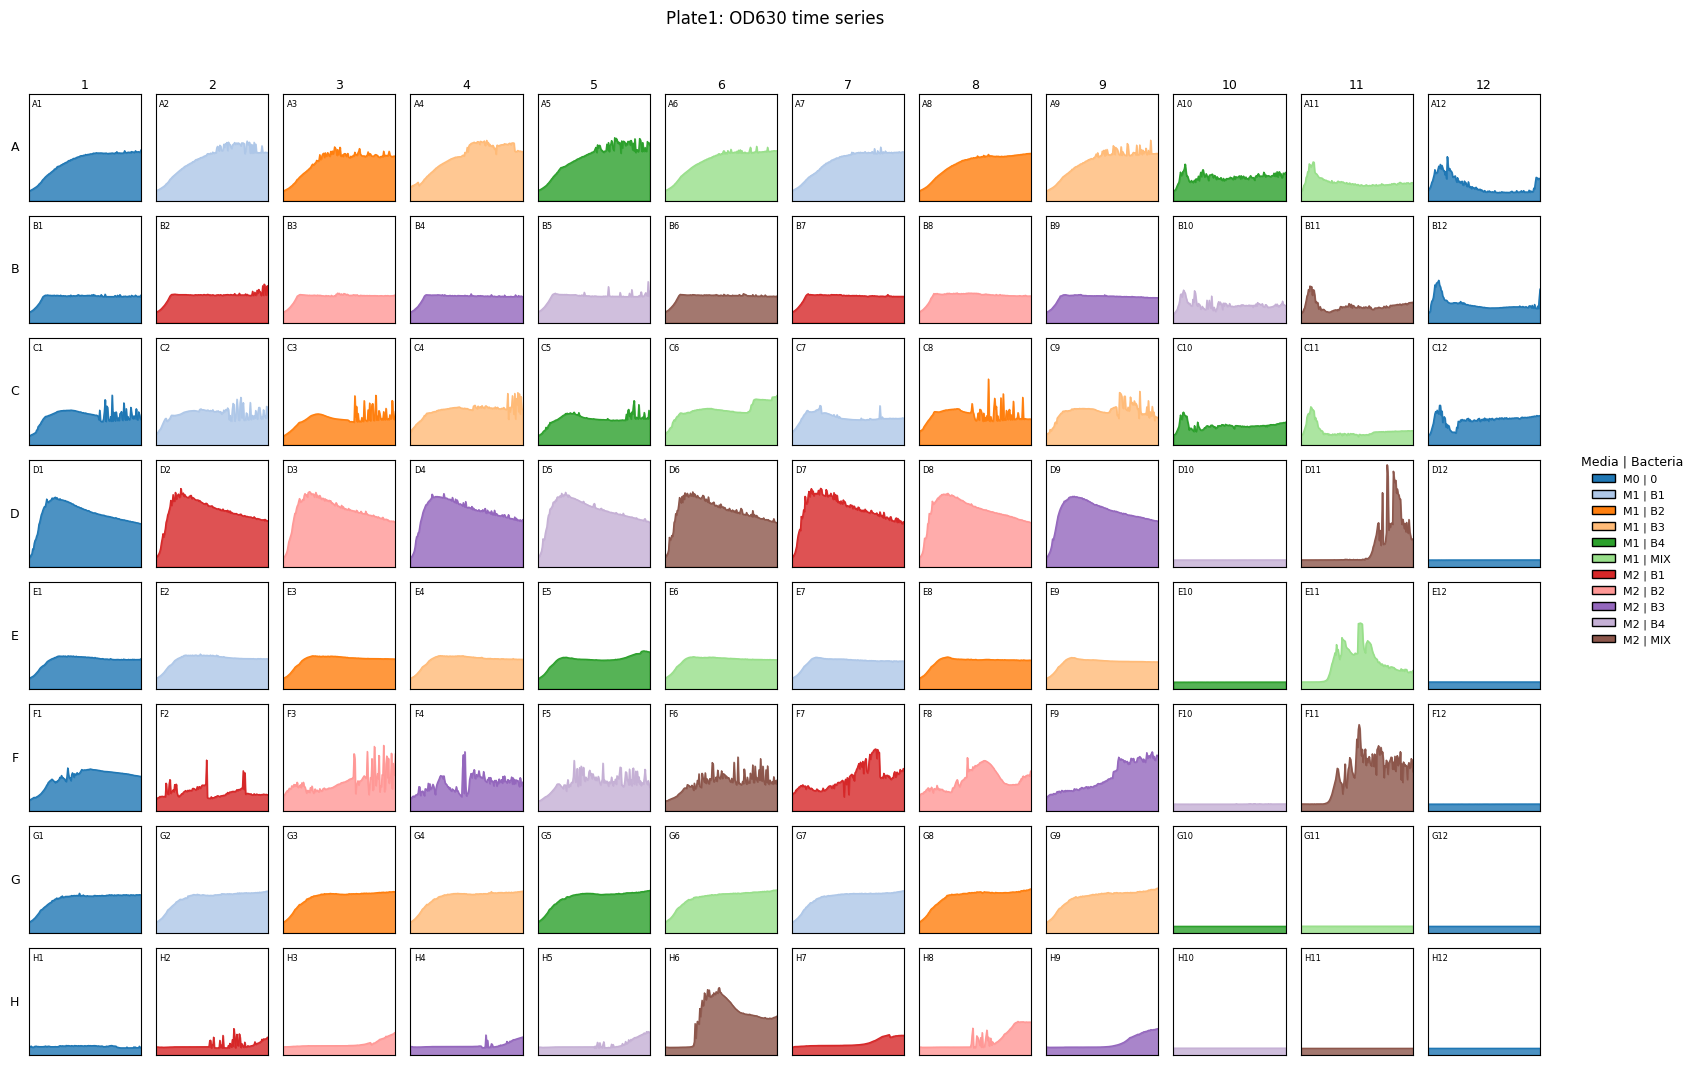

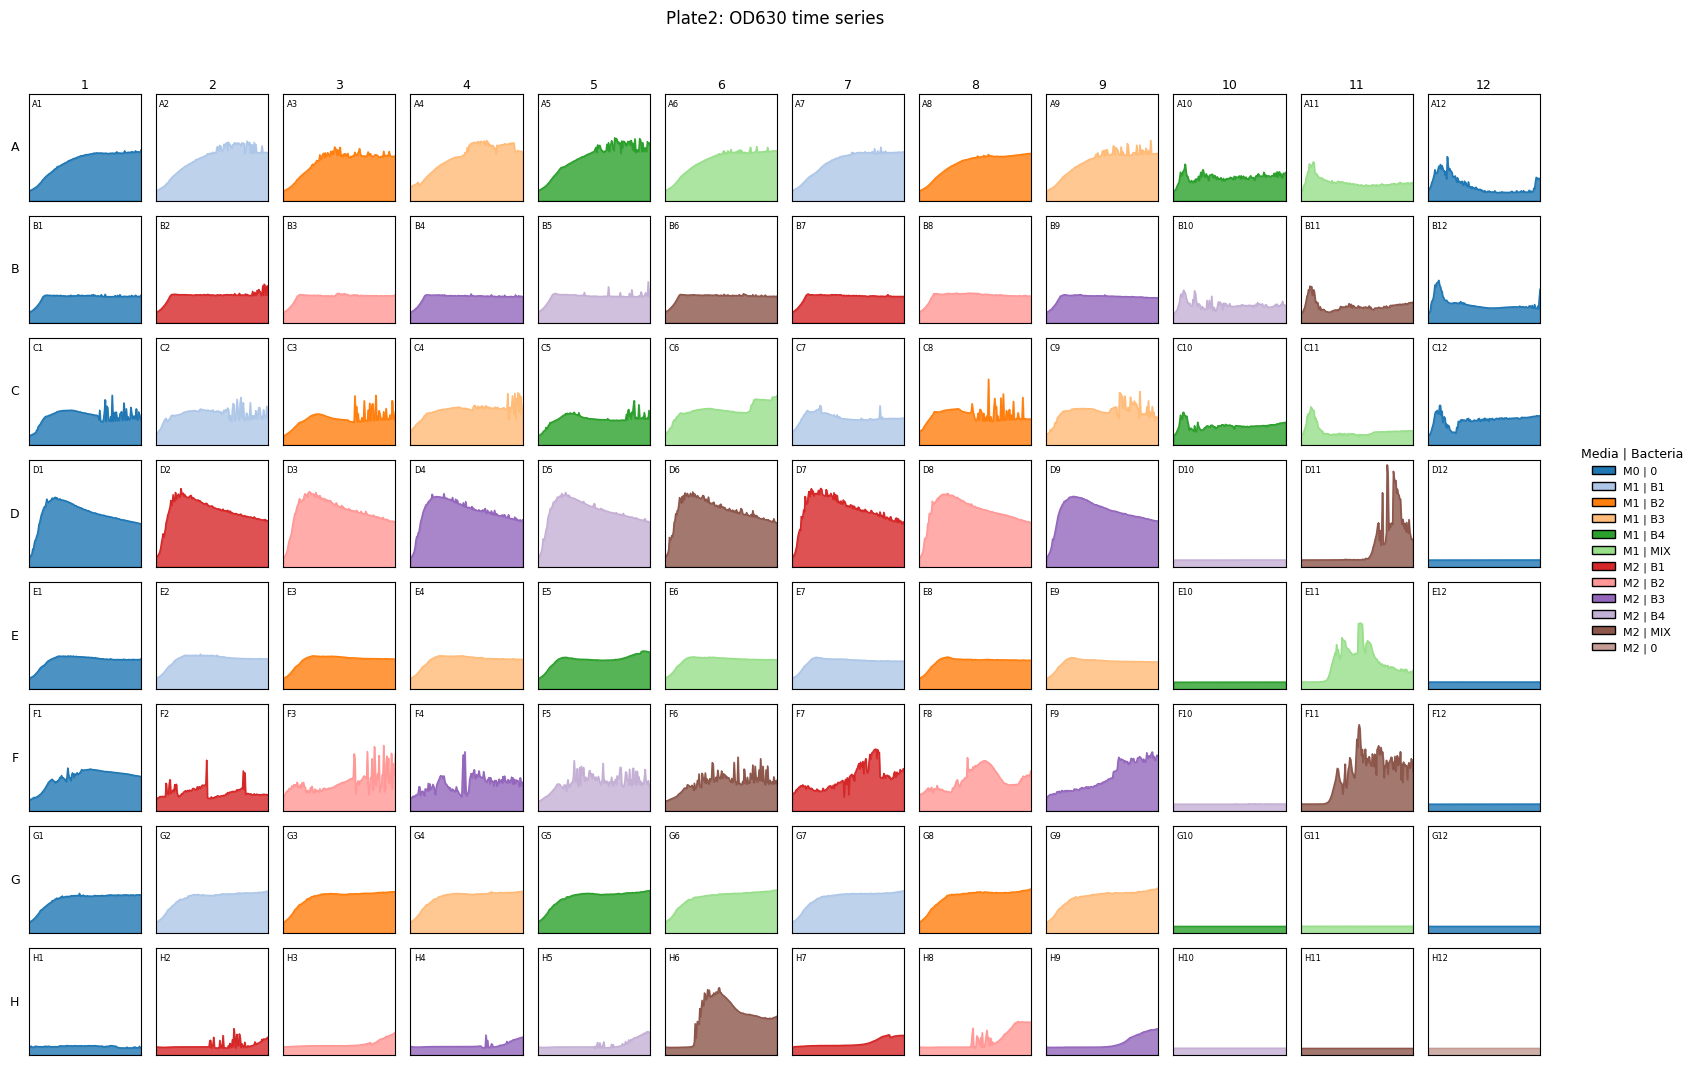

In [19]:
condition_color_map = bplt.make_condition_color_map(experiment)

plate_figures = bplt.plot_plate_overview(
    experiment,
    signal="OD630",
    mode="time_series",
    condition_color_map=condition_color_map,
    show_well_labels=True,
    show_condition_legend=True,
    cell_size=1.3,
)

plt.show()

We can also visualize a single plate:

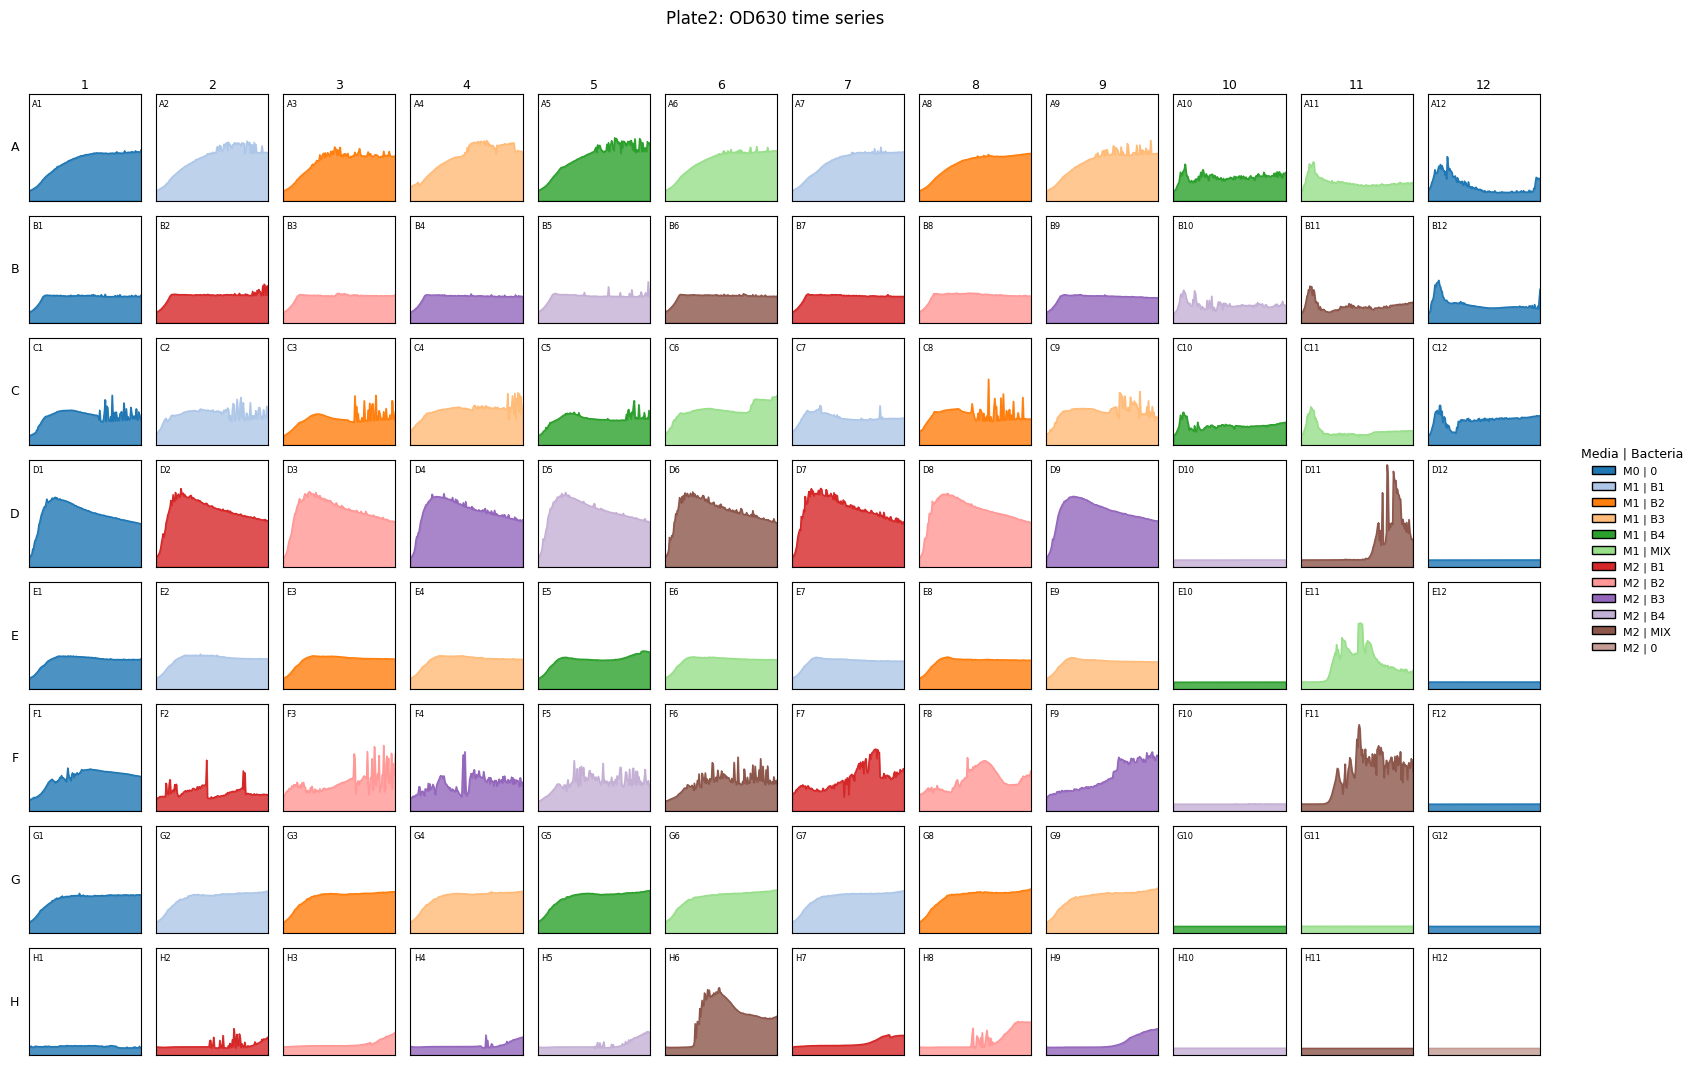

In [20]:
fig, axes = bplt.plot_plate_overview(
    experiment,
    plate_id="Plate2",
    signal="OD630",
    mode="time_series",
    condition_color_map=condition_color_map,
    show_well_labels=True,
    show_condition_legend=True,
    cell_size=1.3,
)

plt.show()

### Inspect a single well

The function `plot_well_data()` plots the time-series data from one selected well. The well is specified through the `well` argument.

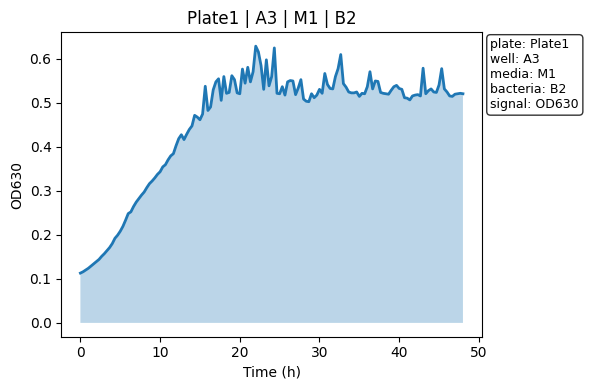

,plate_id,well,signal,n_points,initial_value,final_value,max_value,time_max_value,min_value,time_min_value,...,growthcurves_intrinsic_growth_rate,growthcurves_doubling_time,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse
0,Plate1,A3,OD630,145,0.113,0.52,0.628,22.0,0.113,0.0,...,None,4.454378,1.032947,12.055045,5.306533,0.219731,0.0,48.0,model_fitting_spline,0.024821


In [21]:
plate_id = "Plate1"
well = "A3"
signal = "OD630"

# Plot the curve
bplt.plot_well_data(
    experiment,
    plate_id=plate_id,
    well=well,
    signal=signal,
)

plt.tight_layout()
plt.show()

# Extract the same curve
df_curve = (
    experiment["data"]
    .query("plate_id == @plate_id and well == @well and signal == @signal")
    .copy()
)

# Compute basic + growth-rate metrics
basic_metrics = bp.compute_basic_curve_metrics(
    df_curve,
    time_col="time",
    value_col="value",
    time_points=[12, 24, 48],
)

growth_metrics = bp.compute_growth_rate_metrics(
    df_curve,
    time_col="time",
    value_col="value",
    use_growthcurves=True,
    growthcurves_method="spline",
    window_points=5,
)

# Combine into one row
well_metrics = {
    "plate_id": plate_id,
    "well": well,
    "signal": signal,
    **basic_metrics,
    **growth_metrics,
}

well_metrics_df = pd.DataFrame([well_metrics])
well_metrics_df

### Inspect selected wells together

The function `plot_wells()` plots the time-series data from a user-defined list of wells in the same figure. The wells are passed explicitly through the `wells` argument.

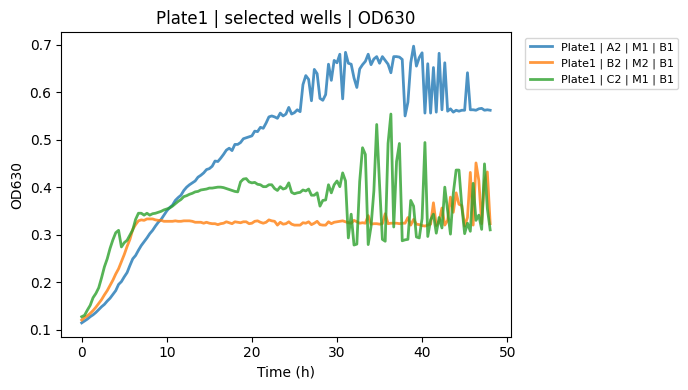

,plate_id,well,signal,n_points,initial_value,final_value,max_value,time_max_value,min_value,time_min_value,...,growthcurves_intrinsic_growth_rate,growthcurves_doubling_time,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse
0,Plate1,A2,OD630,145,0.114,0.562,0.697,39.000000,0.114,0.0,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
1,Plate1,B2,OD630,145,0.120,0.323,0.451,46.333333,0.120,0.0,...,None,2.526221,41.408731,46.234049,45.346734,0.353543,0.0,48.0,model_fitting_spline,0.029482
2,Plate1,C2,OD630,145,0.127,0.310,0.554,36.333333,0.127,0.0,...,None,2.208819,29.160483,33.854350,32.562814,0.369396,0.0,48.0,model_fitting_spline,0.094805


In [22]:
plate_id = "Plate1"
wells = ["A2", "B2", "C2"]
signal = "OD630"

# Plot the selected wells
bplt.plot_wells(
    experiment,
    plate_id=plate_id,
    wells=wells,
    signal=signal,
    fill_area=False,
)

plt.tight_layout()
plt.show()

# Analyze the same curves
rows = []

for well in wells:
    df_curve = (
        experiment["data"]
        .query("plate_id == @plate_id and well == @well and signal == @signal")
        .copy()
    )

    basic_metrics = bp.compute_basic_curve_metrics(
        df_curve,
        time_col="time",
        value_col="value",
        time_points=[12, 24, 48],
    )

    growth_metrics = bp.compute_growth_rate_metrics(
        df_curve,
        time_col="time",
        value_col="value",
        use_growthcurves=True,
        growthcurves_method="spline",
        window_points=5,
    )

    row = {
        "plate_id": plate_id,
        "well": well,
        "signal": signal,
        **basic_metrics,
        **growth_metrics,
    }

    rows.append(row)

well_metrics_df = pd.DataFrame(rows)
well_metrics_df

### Inspect all wells for one condition

The wells for a selected media and bacteria condition can be retrieved with `get_wells_for_condition()` and passed to `plot_wells()`.

In [23]:
this_wells = bplt.get_wells_for_condition(
    experiment,
    media_key="M1",
    bacteria_key="B1",
)
print(this_wells)


   plate_id well media_key bacteria_key row  column
0    Plate1   A2        M1           B1   A       2
1    Plate1   A7        M1           B1   A       7
2    Plate1   C2        M1           B1   C       2
3    Plate1   C7        M1           B1   C       7
4    Plate1   E2        M1           B1   E       2
5    Plate1   E7        M1           B1   E       7
6    Plate1   G2        M1           B1   G       2
7    Plate1   G7        M1           B1   G       7
8    Plate2   A2        M1           B1   A       2
9    Plate2   A7        M1           B1   A       7
10   Plate2   C2        M1           B1   C       2
11   Plate2   C7        M1           B1   C       7
12   Plate2   E2        M1           B1   E       2
13   Plate2   E7        M1           B1   E       7
14   Plate2   G2        M1           B1   G       2
15   Plate2   G7        M1           B1   G       7


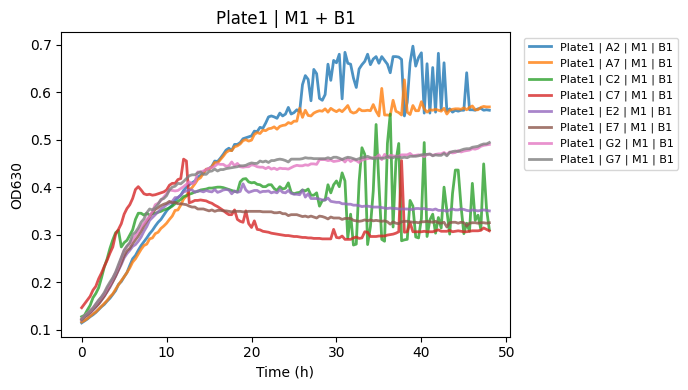

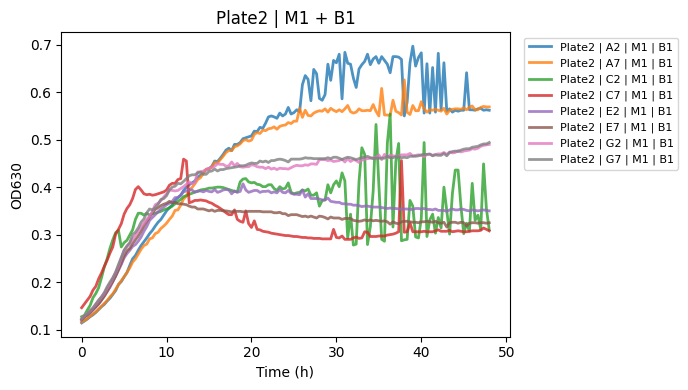

In [24]:
signal = "OD630"

# Plot wells, grouped by plate
for plate_id, df_plate in this_wells.groupby("plate_id"):

    wells = df_plate["well"].tolist()

    bplt.plot_wells(
        experiment,
        plate_id=plate_id,
        wells=wells,
        signal=signal,
        fill_area=False,
        title=f"{plate_id} | M1 + B1",
    )

    plt.tight_layout()
    plt.show()

In [25]:
this_wells_metrics = bp.analyze_wells(
    experiment,
    wells=this_wells,
    signal=signal,
    time_points=[12, 24, 48],
    use_growthcurves=True,
    growthcurves_method="spline",
    window_points=5,
)

this_wells_metrics

,plate_id,well,signal,n_points,initial_value,final_value,max_value,time_max_value,min_value,time_min_value,...,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse,media_key,bacteria_key
0,Plate1,A2,OD630,145,0.114,0.562,0.697,39.000000,0.114,0.0,...,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962,M1,B1
1,Plate1,A7,OD630,145,0.116,0.569,0.626,38.000000,0.116,0.0,...,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101,M1,B1
2,Plate1,C2,OD630,145,0.127,0.310,0.554,36.333333,0.127,0.0,...,29.160483,33.854350,32.562814,0.369396,0.0,48.0,model_fitting_spline,0.094805,M1,B1
3,Plate1,C7,OD630,145,0.146,0.308,0.459,12.000000,0.146,0.0,...,36.192489,37.754414,37.386935,0.350569,0.0,48.0,model_fitting_spline,0.016860,M1,B1
4,Plate1,E2,OD630,145,0.120,0.350,0.407,19.000000,0.120,0.0,...,0.689930,7.776062,4.100503,0.216008,0.0,48.0,model_fitting_spline,0.003631,M1,B1
5,Plate1,E7,OD630,145,0.121,0.325,0.370,10.333333,0.121,0.0,...,0.947126,7.006374,4.582915,0.236622,0.0,48.0,model_fitting_spline,0.002016,M1,B1
6,Plate1,G2,OD630,145,0.123,0.490,0.490,48.000000,0.123,0.0,...,1.138604,8.007181,4.582915,0.245995,0.0,48.0,model_fitting_spline,0.003133,M1,B1
7,Plate1,G7,OD630,145,0.122,0.494,0.494,48.000000,0.122,0.0,...,0.992418,8.044655,4.341709,0.237036,0.0,48.0,model_fitting_spline,0.002477,M1,B1
8,Plate2,A2,OD630,145,0.114,0.562,0.697,39.000000,0.114,0.0,...,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962,M1,B1
9,Plate2,A7,OD630,145,0.116,0.569,0.626,38.000000,0.116,0.0,...,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101,M1,B1




The same plot can also be generated directly with `plot_condition_wells()`, which uses the media and bacteria keys as input instead of an explicit well list.

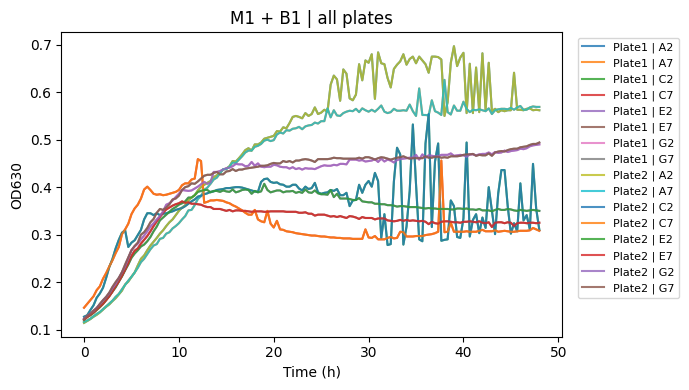

In [26]:
bplt.plot_condition_wells(
    experiment,
    media_key="M1",
    bacteria_key="B1",
    signal="OD630",
)

plt.tight_layout()
plt.show()

### Plot the mean time series for one condition

The function `summarize_growth_data()` calculates the mean over replicate wells at each time point for a selected media and bacteria condition. The resulting summary table is then passed to `plot_summary_curve()` to plot the mean response as a single curve, with optional variation across replicates shown around the mean.

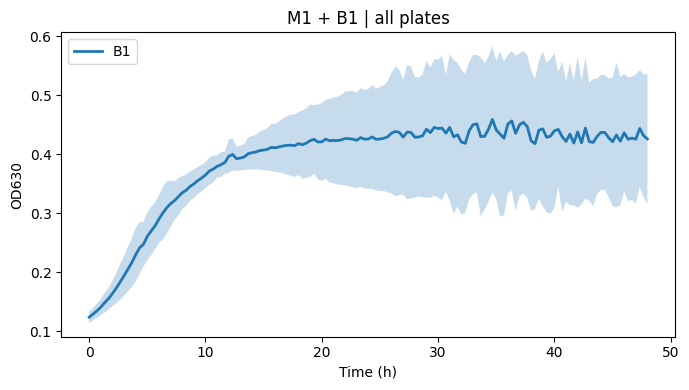

,plate_id,well,media_key,bacteria_key,signal,n_points,initial_value,final_value,max_value,time_max_value,...,growthcurves_intrinsic_growth_rate,growthcurves_doubling_time,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse
0,Plate1,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
1,Plate1,A7,M1,B1,OD630,145,0.116,0.569,0.626,38.000000,...,None,4.872573,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101
2,Plate1,C2,M1,B1,OD630,145,0.127,0.310,0.554,36.333333,...,None,2.208819,29.160483,33.854350,32.562814,0.369396,0.0,48.0,model_fitting_spline,0.094805
3,Plate1,C7,M1,B1,OD630,145,0.146,0.308,0.459,12.000000,...,None,0.945174,36.192489,37.754414,37.386935,0.350569,0.0,48.0,model_fitting_spline,0.016860
4,Plate1,E2,M1,B1,OD630,145,0.120,0.350,0.407,19.000000,...,None,4.021654,0.689930,7.776062,4.100503,0.216008,0.0,48.0,model_fitting_spline,0.003631
5,Plate1,E7,M1,B1,OD630,145,0.121,0.325,0.370,10.333333,...,None,3.757630,0.947126,7.006374,4.582915,0.236622,0.0,48.0,model_fitting_spline,0.002016
6,Plate1,G2,M1,B1,OD630,145,0.123,0.490,0.490,48.000000,...,None,3.444409,1.138604,8.007181,4.582915,0.245995,0.0,48.0,model_fitting_spline,0.003133
7,Plate1,G7,M1,B1,OD630,145,0.122,0.494,0.494,48.000000,...,None,3.495307,0.992418,8.044655,4.341709,0.237036,0.0,48.0,model_fitting_spline,0.002477
8,Plate2,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
9,Plate2,A7,M1,B1,OD630,145,0.116,0.569,0.626,38.000000,...,None,4.872573,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101


In [27]:
media_key = "M1"
bacteria_key = "B1"
signal = "OD630"

# Plot the summary curve across all plates
summary = bp.summarize_growth_data(
    experiment,
    media_key=media_key,
    bacteria_key=bacteria_key,
    signal=signal,
)

bplt.plot_summary_curve(
    summary,
    signal=signal,
    title=f"{media_key} + {bacteria_key} | all plates",
    label=bacteria_key,
)

plt.tight_layout()
plt.show()

points, metrics_summary = bp.analyze_growth_curves(
    experiment,
    media_key="M1",
    bacteria_key="B1",
    signal="OD630",
    time_points=[12, 24, 48],
    use_growthcurves=True,
    growthcurves_method="spline",
    window_points=5,
)

points


In [28]:
metrics_summary

,metric,mean,std,count
0,n_points,145.000000,0.000000,16.0
1,initial_value,0.123625,0.009563,16.0
2,final_value,0.426000,0.110165,16.0
3,max_value,0.512125,0.105698,16.0
4,time_max_value,31.333333,14.835393,16.0
5,min_value,0.123625,0.009563,16.0
6,time_min_value,0.000000,0.000000,16.0
7,auc,18.687646,2.994646,16.0
8,value_at_12h,0.396750,0.028311,16.0
9,actual_time_at_12h,12.000000,0.000000,16.0


### Compare multiple bacteria conditions within one medium

The function `plot_bacteria_comparison()` compares selected bacteria conditions within one media condition. For each bacteria condition, replicate wells are summarized over time and plotted together in a single figure.

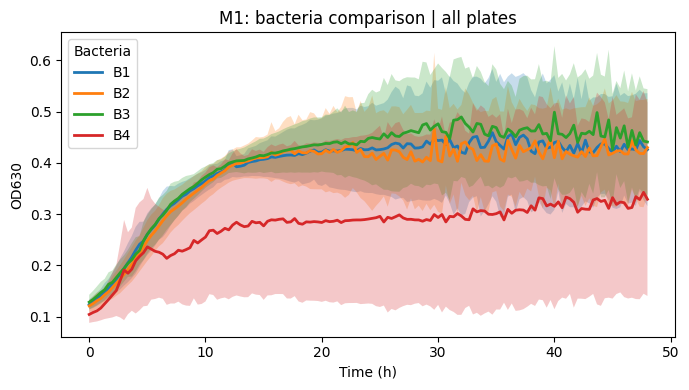

,plate_id,well,media_key,bacteria_key,signal,n_points,initial_value,final_value,max_value,time_max_value,...,growthcurves_intrinsic_growth_rate,growthcurves_doubling_time,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse
0,Plate1,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228e+00,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,2.896247e-02
1,Plate1,A7,M1,B1,OD630,145,0.116,0.569,0.626,38.000000,...,None,4.872573e+00,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,1.110079e-02
2,Plate1,C2,M1,B1,OD630,145,0.127,0.310,0.554,36.333333,...,None,2.208819e+00,29.160483,33.854350,32.562814,0.369396,0.0,48.0,model_fitting_spline,9.480476e-02
3,Plate1,C7,M1,B1,OD630,145,0.146,0.308,0.459,12.000000,...,None,9.451744e-01,36.192489,37.754414,37.386935,0.350569,0.0,48.0,model_fitting_spline,1.686026e-02
4,Plate1,E2,M1,B1,OD630,145,0.120,0.350,0.407,19.000000,...,None,4.021654e+00,0.689930,7.776062,4.100503,0.216008,0.0,48.0,model_fitting_spline,3.630624e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,Plate2,C5,M1,B4,OD630,145,0.104,0.312,0.515,41.333333,...,None,1.891077e+00,37.005559,41.370144,40.763819,0.412373,0.0,48.0,model_fitting_spline,4.563163e-02
60,Plate2,E10,M1,B4,OD630,145,0.078,0.079,0.079,1.333333,...,None,1.367720e+01,7.810470,11.770111,9.889447,0.078622,0.0,48.0,model_fitting_spline,1.358939e-05
61,Plate2,E5,M1,B4,OD630,145,0.115,0.430,0.443,45.333333,...,None,3.706854e+00,0.898838,8.111163,4.100503,0.209268,0.0,48.0,model_fitting_spline,1.070876e-03
62,Plate2,G10,M1,B4,OD630,145,0.079,0.079,0.079,0.000000,...,None,1.684005e+14,0.000000,48.000000,0.723618,0.079000,0.0,48.0,model_fitting_spline,3.172503e-16


In [29]:
media_key = "M1"
bacteria_keys = ["B1", "B2", "B3", "B4"]
signal = "OD630"

# Plot the selected bacteria conditions in one medium
bplt.plot_bacteria_comparison(
    experiment,
    media_key=media_key,
    bacteria_keys=bacteria_keys,
    signal=signal,
)

plt.tight_layout()
plt.show()

# Analyze the same conditions
all_points = []
all_summaries = []

for bacteria_key in bacteria_keys:
    points, summary = bp.analyze_growth_curves(
        experiment,
        media_key=media_key,
        bacteria_key=bacteria_key,
        signal=signal,
        time_points=[12, 24, 48],
        use_growthcurves=True,
        growthcurves_method="spline",
        window_points=5,
    )

    all_points.append(points)
    all_summaries.append(summary)

bacteria_comparison_points = pd.concat(all_points, ignore_index=True)
bacteria_comparison_points


In [30]:

bacteria_comparison_summary = pd.concat(all_summaries, ignore_index=True)

display(bprs.format_metrics_summary(bacteria_comparison_summary))

,Metric,mean ± std,n
0,n_points,145.0 ± 0.0,16.0
1,initial_value,0.124 ± 0.01,16.0
2,final_value,0.426 ± 0.11,16.0
3,max_value,0.512 ± 0.106,16.0
4,time_max_value,31.333 ± 14.835,16.0
...,...,...,...
107,growthcurves_time_at_umax,13.417 ± 17.322,16.0
108,growthcurves_od_at_umax,0.259 ± 0.181,16.0
109,growthcurves_fit_t_min,0.0 ± 0.0,16.0
110,growthcurves_fit_t_max,48.0 ± 0.0,16.0


### Compare one bacteria condition across media

The function `plot_media_comparison()` compares one bacteria condition across selected media conditions. For each media condition, replicate wells are summarized over time and plotted together in a single figure.

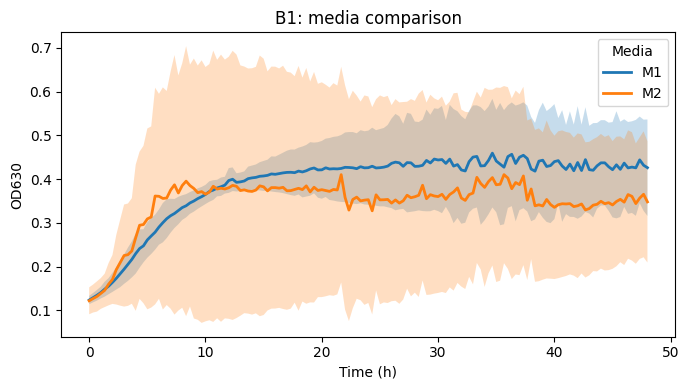

,plate_id,well,media_key,bacteria_key,signal,n_points,initial_value,final_value,max_value,time_max_value,...,growthcurves_intrinsic_growth_rate,growthcurves_doubling_time,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse
0,Plate1,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
1,Plate1,A7,M1,B1,OD630,145,0.116,0.569,0.626,38.000000,...,None,4.872573,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101
2,Plate1,C2,M1,B1,OD630,145,0.127,0.310,0.554,36.333333,...,None,2.208819,29.160483,33.854350,32.562814,0.369396,0.0,48.0,model_fitting_spline,0.094805
3,Plate1,C7,M1,B1,OD630,145,0.146,0.308,0.459,12.000000,...,None,0.945174,36.192489,37.754414,37.386935,0.350569,0.0,48.0,model_fitting_spline,0.016860
4,Plate1,E2,M1,B1,OD630,145,0.120,0.350,0.407,19.000000,...,None,4.021654,0.689930,7.776062,4.100503,0.216008,0.0,48.0,model_fitting_spline,0.003631
5,Plate1,E7,M1,B1,OD630,145,0.121,0.325,0.370,10.333333,...,None,3.757630,0.947126,7.006374,4.582915,0.236622,0.0,48.0,model_fitting_spline,0.002016
6,Plate1,G2,M1,B1,OD630,145,0.123,0.490,0.490,48.000000,...,None,3.444409,1.138604,8.007181,4.582915,0.245995,0.0,48.0,model_fitting_spline,0.003133
7,Plate1,G7,M1,B1,OD630,145,0.122,0.494,0.494,48.000000,...,None,3.495307,0.992418,8.044655,4.341709,0.237036,0.0,48.0,model_fitting_spline,0.002477
8,Plate2,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
9,Plate2,A7,M1,B1,OD630,145,0.116,0.569,0.626,38.000000,...,None,4.872573,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101


In [31]:
media_keys = ["M1", "M2"]
bacteria_key = "B1"
signal = "OD630"

# Plot the selected media conditions for one bacteria
bplt.plot_media_comparison(
    experiment,
    media_keys=media_keys,
    bacteria_key=bacteria_key,
    signal=signal,
)

plt.tight_layout()
plt.show()

# Analyze the same conditions
all_points = []
all_summaries = []

for media_key in media_keys:
    points, summary = bp.analyze_growth_curves(
        experiment,
        media_key=media_key,
        bacteria_key=bacteria_key,
        signal=signal,
        time_points=[12, 24, 48],
        use_growthcurves=True,
        growthcurves_method="spline",
        window_points=5,
    )

    all_points.append(points)
    all_summaries.append(summary)

media_comparison_points = pd.concat(all_points, ignore_index=True)
media_comparison_points

In [32]:

media_comparison_summary = pd.concat(all_summaries, ignore_index=True)
display(bprs.format_metrics_summary(media_comparison_summary))

,Metric,mean ± std,n
0,n_points,145.0 ± 0.0,16.0
1,initial_value,0.124 ± 0.01,16.0
2,final_value,0.426 ± 0.11,16.0
3,max_value,0.512 ± 0.106,16.0
4,time_max_value,31.333 ± 14.835,16.0
5,min_value,0.124 ± 0.01,16.0
6,time_min_value,0.0 ± 0.0,16.0
7,auc,18.688 ± 2.995,16.0
8,value_at_12h,0.397 ± 0.028,16.0
9,actual_time_at_12h,12.0 ± 0.0,16.0


Compare the same bacteria key across two or more media conditions.


In [33]:
conditions = bp.list_conditions(experiment)
conditions

,media_key,bacteria_key
0,M0,0
1,M1,B1
2,M1,B2
3,M1,B3
4,M1,B4
5,M1,MIX
6,M2,0
7,M2,B1
8,M2,B2
9,M2,B3


### Compare all bacteria conditions within one medium

The function `plot_all_bacteria_in_media()` plots all bacteria conditions present within a selected media condition. For each bacteria condition, replicate wells are summarized over time and plotted in the same figure.

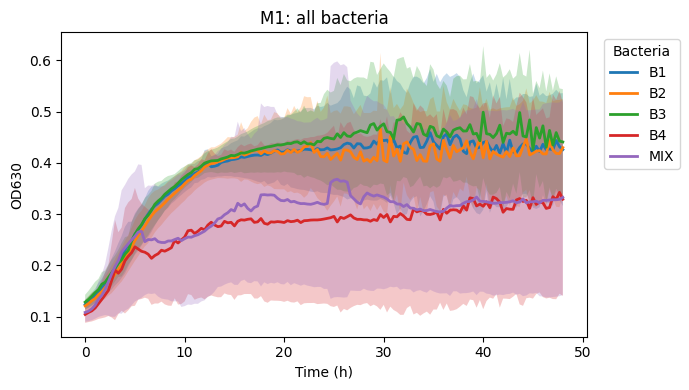

In [34]:
media_key = "M1"
signal = "OD630"

# Plot all bacteria conditions within one medium
bplt.plot_all_bacteria_in_media(
    experiment,
    media_key=media_key,
    signal=signal,
)

plt.tight_layout()
plt.show()


In [35]:

# Analyze the same set of curves
all_bacteria_points, all_bacteria_summary = bp.analyze_growth_curves(
    experiment,
    media_key=media_key,
    bacteria_key=None,
    signal=signal,
    time_points=[12, 24, 48],
    use_growthcurves=True,
    growthcurves_method="spline",
    window_points=5,
)
all_bacteria_points

,plate_id,well,media_key,bacteria_key,signal,n_points,initial_value,final_value,max_value,time_max_value,...,growthcurves_intrinsic_growth_rate,growthcurves_doubling_time,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse
0,Plate1,A10,M1,B4,OD630,145,0.107,0.329,0.427,5.000000,...,None,1.940542,0.166126,4.040661,1.688442,0.184304,0.0,48.0,model_fitting_spline,0.061765
1,Plate1,A11,M1,MIX,OD630,145,0.107,0.210,0.452,5.333333,...,None,1.620302,0.277989,3.646131,1.929648,0.216890,0.0,48.0,model_fitting_spline,0.029919
2,Plate1,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
3,Plate1,A3,M1,B2,OD630,145,0.113,0.520,0.628,22.000000,...,None,4.454378,1.032947,12.055045,5.306533,0.219731,0.0,48.0,model_fitting_spline,0.024821
4,Plate1,A4,M1,B3,OD630,145,0.153,0.572,0.705,32.666667,...,None,4.298639,2.977901,12.452496,5.306533,0.222722,0.0,48.0,model_fitting_spline,0.018055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Plate2,G5,M1,B4,OD630,145,0.124,0.497,0.497,48.000000,...,None,3.471317,1.066112,8.018832,4.582915,0.250263,0.0,48.0,model_fitting_spline,0.001579
76,Plate2,G6,M1,MIX,OD630,145,0.125,0.502,0.502,48.000000,...,None,3.633962,0.962762,8.251615,4.582915,0.249342,0.0,48.0,model_fitting_spline,0.002229
77,Plate2,G7,M1,B1,OD630,145,0.122,0.494,0.494,48.000000,...,None,3.495307,0.992418,8.044655,4.341709,0.237036,0.0,48.0,model_fitting_spline,0.002477
78,Plate2,G8,M1,B2,OD630,145,0.128,0.516,0.516,48.000000,...,None,3.730011,0.837994,8.339894,3.859296,0.224411,0.0,48.0,model_fitting_spline,0.003299


In [36]:
display(bprs.format_metrics_summary(all_bacteria_summary))

,Metric,mean ± std,n
0,n_points,145.0 ± 0.0,80.0
1,initial_value,0.117 ± 0.017,80.0
2,final_value,0.392 ± 0.149,80.0
3,max_value,0.495 ± 0.165,80.0
4,time_max_value,28.858 ± 17.544,80.0
5,min_value,0.117 ± 0.017,80.0
6,time_min_value,0.625 ± 3.874,80.0
7,auc,16.804 ± 5.273,80.0
8,value_at_12h,0.345 ± 0.106,80.0
9,actual_time_at_12h,12.0 ± 0.0,80.0


### Compare one bacteria condition between two media

The function `compare_two_media()` compares one bacteria condition between two selected media conditions. The two media keys are passed as `media1` and `media2`, and the bacteria condition is specified with `bacteria_key`.

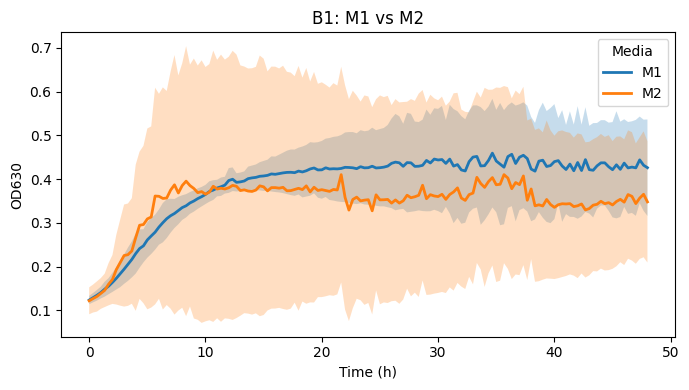

In [37]:
media_keys = ["M1", "M2"]
bacteria_key = "B1"
signal = "OD630"

# Plot: equivalent versions
bplt.compare_two_media(
    experiment,
    media1=media_keys[0],
    media2=media_keys[1],
    bacteria_key=bacteria_key,
    signal=signal,
)

plt.tight_layout()
plt.show()


In [38]:

all_points = []

for media_key in media_keys:
    points, summary = bp.analyze_growth_curves(
        experiment,
        media_key=media_key,
        bacteria_key=bacteria_key,
        signal=signal,
        time_points=[12, 24, 48],
        use_growthcurves=True,
        growthcurves_method="spline",
        window_points=5,
    )

    all_points.append(points)

media_comparison_points = pd.concat(all_points, ignore_index=True)

media_comparison_points

,plate_id,well,media_key,bacteria_key,signal,n_points,initial_value,final_value,max_value,time_max_value,...,growthcurves_intrinsic_growth_rate,growthcurves_doubling_time,growthcurves_exp_phase_start,growthcurves_exp_phase_end,growthcurves_time_at_umax,growthcurves_od_at_umax,growthcurves_fit_t_min,growthcurves_fit_t_max,growthcurves_fit_method,growthcurves_model_rmse
0,Plate1,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
1,Plate1,A7,M1,B1,OD630,145,0.116,0.569,0.626,38.000000,...,None,4.872573,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101
2,Plate1,C2,M1,B1,OD630,145,0.127,0.310,0.554,36.333333,...,None,2.208819,29.160483,33.854350,32.562814,0.369396,0.0,48.0,model_fitting_spline,0.094805
3,Plate1,C7,M1,B1,OD630,145,0.146,0.308,0.459,12.000000,...,None,0.945174,36.192489,37.754414,37.386935,0.350569,0.0,48.0,model_fitting_spline,0.016860
4,Plate1,E2,M1,B1,OD630,145,0.120,0.350,0.407,19.000000,...,None,4.021654,0.689930,7.776062,4.100503,0.216008,0.0,48.0,model_fitting_spline,0.003631
5,Plate1,E7,M1,B1,OD630,145,0.121,0.325,0.370,10.333333,...,None,3.757630,0.947126,7.006374,4.582915,0.236622,0.0,48.0,model_fitting_spline,0.002016
6,Plate1,G2,M1,B1,OD630,145,0.123,0.490,0.490,48.000000,...,None,3.444409,1.138604,8.007181,4.582915,0.245995,0.0,48.0,model_fitting_spline,0.003133
7,Plate1,G7,M1,B1,OD630,145,0.122,0.494,0.494,48.000000,...,None,3.495307,0.992418,8.044655,4.341709,0.237036,0.0,48.0,model_fitting_spline,0.002477
8,Plate2,A2,M1,B1,OD630,145,0.114,0.562,0.697,39.000000,...,None,3.586228,29.733215,39.100892,38.592965,0.631825,0.0,48.0,model_fitting_spline,0.028962
9,Plate2,A7,M1,B1,OD630,145,0.116,0.569,0.626,38.000000,...,None,4.872573,0.732602,12.582884,3.859296,0.180978,0.0,48.0,model_fitting_spline,0.011101


In [39]:
metadata_cols = ["plate_id", "well", "media_key", "bacteria_key", "signal"]

numeric_cols = [
    col for col in media_comparison_points.columns
    if col not in metadata_cols
    and pd.api.types.is_numeric_dtype(media_comparison_points[col])
]

media_comparison_summary = (
    media_comparison_points
    .groupby("media_key")[numeric_cols]
    .agg(["mean", "std", "count"])
)

media_comparison_summary

n_points            initial_value                 final_value  \
              mean  std count          mean       std count        mean   
media_key                                                                 
M1           145.0  0.0    16      0.123625  0.009563    16    0.426000   
M2           145.0  0.0    16      0.121875  0.030800    16    0.347875   

                          max_value  ... growthcurves_od_at_umax  \
                std count      mean  ...                   count   
media_key                            ...                           
M1         0.110165    16  0.512125  ...                      16   
M2         0.138604    16  0.560625  ...                      16   

          growthcurves_fit_t_min            growthcurves_fit_t_max             \
                            mean  std count                   mean  std count   
media_key                                                                       
M1                           0.0  0.0    16                   48.0  0.0    16   
M2                           0.0  0.0    16                   48.0  0.0    16   

          growthcurves_model_rmse                  
                             mean       std count  
media_key                                          
M1                       0.020373  0.030435    16  
M2                       0.059869  0.058096    16  

[2 rows x 84 columns]

This is equivalent to using the more general function:

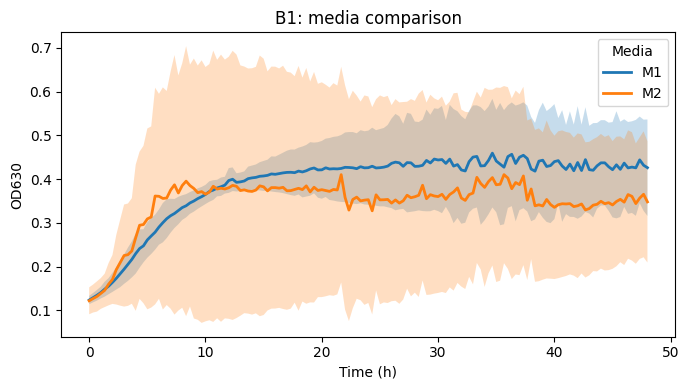

In [40]:
bplt.plot_media_comparison(
    experiment,
    media_keys=["M1", "M2"],
    bacteria_key="B1",
    signal="OD630",
)

plt.tight_layout()
plt.show()